# Static Inverse Design of Scissor Mechanisms (Shape Morphing)

**Reference:** *Morphing of and writing with a scissor linkage mechanism*, Mohanraj A. and S. Ganga Prasath.

This notebook implements the numerical framework for the **static shape morphing task**. The goal is to determine a sequence of aspect ratios $\{\alpha_j\}$ and a single, specific actuation input $\Psi^*$ such that the deployed configuration matches a prescribed target shape precisely at that actuation state.

Unlike trajectory tracing (where the tip traces a path over a sweep of $\Psi$), shape morphing focuses on matching the entire physical curve of the mechanism to a target geometry for a fixed $\Psi^*$.

## 1. Target Processing: Discretizing and Evaluating Target Curvature

**Theory:**
To evaluate the target curvature, the continuous target curve is discretized into $M$ segments of equal arc length $\Delta s = L_{\mathrm{target}}/M$, yielding $M+1$ nodes corresponding to the boundaries of the $M$ units of the mechanism. The discrete target node positions $\mathbf{p}_j = (x(j\Delta s), y(j\Delta s))$ are obtained using spline interpolants.

The target curvature $\kappa_j^t$ at each node is then computed using the spatial derivatives of the arc-length parameterized curve.

Running on device: cuda
Total arc length       : 7.7501
Curve points           : (56, 2)  (N+1 equidistant)
Curvature range        :[-7.088, 6.688]
Initial tangent angle  : 30.96°


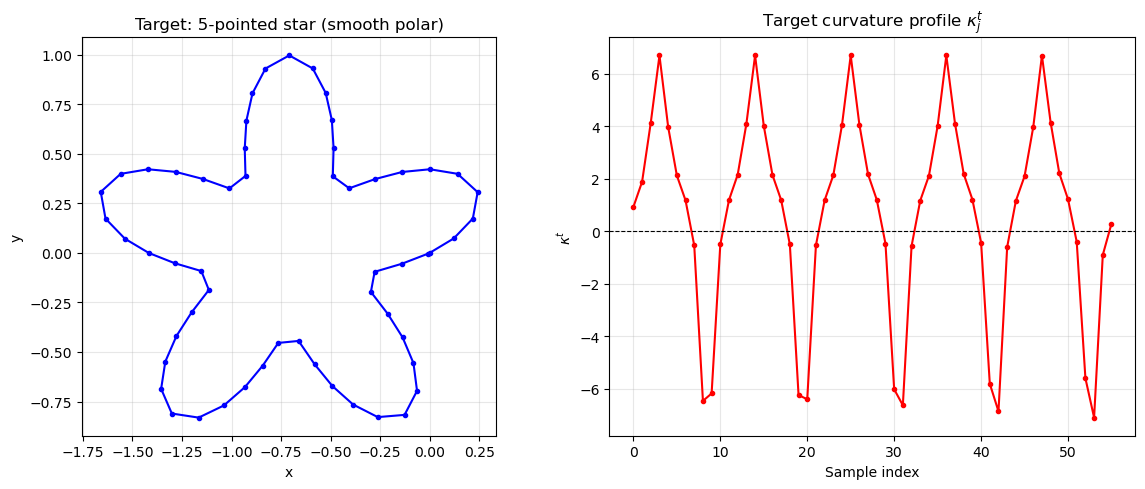

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on device: {device}')

class StarTargetCurve:
    """
    Generate a 5-pointed star as a smooth closed polar curve and extract
    the arc-length parameterised coordinates and signed curvature profile.

    The star radius at angle theta is:
        r(theta) = r_inner + (r_outer - r_inner) * (1 + sin(num_arms * theta)) / 2

    Parameters
    ----------
    num_points   : dense sampling resolution for arc-length integration
    num_arms     : number of star tips (default 5)
    inner_radius : radius at the inner notches
    outer_radius : radius at the outer tips
    n_units      : number of scissor units N; curve is resampled to N+1 equidistant points
    """
    def __init__(self,
                 num_points: int   = 1000,
                 num_arms: int     = 5,
                 inner_radius: float = 0.4,
                 outer_radius: float = 1.0,
                 n_units: int      = 34):

        self.num_equidistant_points = n_units + 1

        self.s_total, self.target_coords, self.target_curvatures = \
            self._generate_star(num_points, num_arms, inner_radius, outer_radius)

        # Initial tangent direction: angle of vector from point 0 to point 1
        p1 = self.target_coords[1]
        self.initial_tangent_angle = np.arctan2(p1[1], p1[0])

    def _generate_star(self, num_points, num_arms, inner_r, outer_r):
        # ---- Step 1: Dense polar star curve ----
        # theta sweeps 0 → 2π; sinusoidal modulation of r creates the star shape.
        theta = np.linspace(0, 2 * np.pi, num_points)
        r = inner_r + (outer_r - inner_r) * (1 + np.sin(num_arms * theta)) / 2
        x = r * np.cos(theta)
        y = r * np.sin(theta)

        # ---- Step 2: Arc-length parameterisation ----
        dx = np.diff(x)
        dy = np.diff(y)
        ds = np.sqrt(dx**2 + dy**2)
        s = np.concatenate(([0], cumulative_trapezoid(ds, initial=0)))

        # ---- Step 3: Resample to N+1 equidistant arc-length points ----
        fx = interp1d(s, x, kind='linear')
        fy = interp1d(s, y, kind='linear')
        s_steps = np.linspace(0, s[-1], self.num_equidistant_points)
        x_eq = fx(s_steps)
        y_eq = fy(s_steps)

        # ---- Step 4: Signed curvature via finite differences ----
        dx_eq  = np.gradient(x_eq,  s_steps)
        dy_eq  = np.gradient(y_eq,  s_steps)
        ddx_eq = np.gradient(dx_eq, s_steps)
        ddy_eq = np.gradient(dy_eq, s_steps)

        curvature = (dx_eq * ddy_eq - dy_eq * ddx_eq) / \
                     np.power(dx_eq**2 + dy_eq**2, 1.5)

        # ---- Step 5: Shift so the curve starts at the origin ----
        coords = np.stack([x_eq, y_eq], axis=1)
        coords -= coords[0]

        return s[-1], coords, torch.tensor(curvature, dtype=torch.float32)

# --- Generate and preview ---
N_UNITS = 55
target_data = StarTargetCurve(
    num_points=1000, num_arms=5,
    inner_radius=0.4, outer_radius=1.0,
    n_units=N_UNITS
)

print(f'Total arc length       : {target_data.s_total:.4f}')
print(f'Curve points           : {target_data.target_coords.shape}  (N+1 equidistant)')
print(f'Curvature range        :[{target_data.target_curvatures.min():.3f}, {target_data.target_curvatures.max():.3f}]')
print(f'Initial tangent angle  : {np.degrees(target_data.initial_tangent_angle):.2f}°')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
t_xy = target_data.target_coords
axes[0].plot(t_xy[:, 0], t_xy[:, 1], 'b-o', ms=3, lw=1.5)
axes[0].set_aspect('equal')
axes[0].set_title('Target: 5-pointed star (smooth polar)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

axes[1].plot(target_data.target_curvatures.numpy(), 'r-o', ms=3)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_title('Target curvature profile $\kappa^t_j$')
axes[1].set_xlabel('Sample index'); axes[1].set_ylabel('$\kappa^t$')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Discrete Forward Kinematics & Shape Morphing as Inverse Design

**Theory:**
The configuration of the mechanism is governed by the forward kinematics map $\mathcal{F}:(\Psi,l,\beta_0,\{\alpha_j\}) \longrightarrow \{\mathbf{r}_j\}$. The local curvature of the $j$-th unit is defined intrinsically as $\kappa_j(\alpha_j,\phi_j(\Psi),l)$.

We pose static shape-morphing as the minimization of a composite loss function over the design variables $\mathbf{x} = \{\,l,\;\Psi,\;\beta_0,\;\alpha_1,\dots,\alpha_M\,\}^{\mathsf{T}}$:

$$
\mathcal{L}[\mathbf{x}] = \lambda_{\kappa} \sum_{j=1}^M\big(\kappa_j(\alpha_j,\phi_j,l)-\kappa_j^t\big)^2 + \lambda_{\mathrm{tip}} \|\mathbf{r}_M-\mathbf{p}_{M}\|^2 + \lambda_{\mathrm{rot}} (\beta_0 - \theta_{\mathrm{target}})^2
$$

In implementation, we also include a total length constraint and a smoothness regularizer for practical manufacturability.

In [2]:
class ScissorInverseDesign(nn.Module):
    """
    Differentiable scissor linkage mechanism for inverse design (shape morphing).

    All four design variables are learnable nn.Parameters:
      alpha_logits — unconstrained, mapped to alpha_j in (0.3, 0.7)
      log_l        — log of arm length (always positive after exp)
      psi_star     — deployment actuation angle Psi* (radians)
      init_rot     — initial orientation beta_0 of the first unit (radians)
    """

    def __init__(self, n_units: int, target_data):
        super().__init__()
        self.n_units = n_units

        # Initialise l so that l ≈ average segment length of the target curve.
        # This gives a physically sensible starting scale and speeds up convergence.
        avg_step = target_data.s_total / n_units
        self.log_l = nn.Parameter(torch.tensor(np.log(avg_step), dtype=torch.float32))

        # Small positive bias breaks alpha=0.5 symmetry (zero curvature everywhere)
        # while keeping the initialisation close to a straight deployment.
        self.alpha_logits = nn.Parameter(
            torch.zeros(n_units, dtype=torch.float32) + 0.1
        )

        # psi_star: start at pi/2 (~90°), a mid-range actuation angle
        self.psi_star = nn.Parameter(torch.tensor(1.57, dtype=torch.float32))

        # init_rot: start aligned with positive x-axis; optimiser adjusts it
        self.init_rot = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

        # Register target data as non-learnable buffers (moves to correct device)
        self.register_buffer('target_pos',
            torch.tensor(target_data.target_coords, dtype=torch.float32))
        self.register_buffer('target_k', target_data.target_curvatures)
        self.register_buffer('target_arc_len',
            torch.tensor(target_data.s_total, dtype=torch.float32))
        self.register_buffer('target_angle',
            torch.tensor(target_data.initial_tangent_angle, dtype=torch.float32))

    def get_alpha(self) -> torch.Tensor:
        """
        Map alpha_logits ∈ ℝ  →  alpha_j ∈ (0.3, 0.7) via sigmoid.
        The (0.3, 0.7) range keeps units away from the degenerate limits
        alpha=0 and alpha=1 while covering both positive (>0.5) and
        negative (<0.5) curvature regimes.
        """
        return 0.3 + 0.4 * torch.sigmoid(self.alpha_logits)

    def get_l(self) -> torch.Tensor:
        """Arm length l = exp(log_l), always positive."""
        return torch.exp(self.log_l)

    def forward(self):
        alpha = self.get_alpha()
        l = self.get_l()
        psi = self.psi_star
        rot = self.init_rot
        
        a = alpha.unsqueeze(0)
        Psi = psi.unsqueeze(0)
        
        # --- 1. Solve Unit Angles (Phi) ---
        phi_list = [Psi]
        curr_phi = Psi
        
        for j in range(self.n_units - 1):
            aj, aj1 = a[:, j], a[:, j+1]
            d_sq = aj**2 + (1-aj)**2 - 2*aj*(1-aj)*torch.cos(curr_phi)
            term_num = aj1**2 + (1-aj1)**2 - d_sq
            term_den = 2*aj1*(1-aj1) + 1e-6
            cosv = torch.clamp(term_num / term_den, -1.0 + 1e-6, 1.0 - 1e-6)
            next_phi = torch.acos(cosv)
            phi_list.append(next_phi)
            curr_phi = next_phi

        phi = torch.stack(phi_list, dim=1)
        angle_in = torch.clamp((np.pi - phi)/2, 0.01, 1.56)
        phi_s = 2 * torch.atan((2*a - 1) * torch.tan(angle_in))

        # --- 2. Compute Global Angles (Theta) ---
        T1_l, T2_l = [Psi/2 + rot],[-Psi/2 + rot]
        
        if self.n_units > 1:
            T1_l.append(-0.5*(phi_s[:,1]-phi[:,1]+phi_s[:,0]) + rot)
            T2_l.append(-0.5*(phi_s[:,1]+phi[:,1]+phi_s[:,0]) + rot)
            
        c_phi = phi_s[:,1].clone()
        for j in range(2, self.n_units):
            val_T1 = -(c_phi + 0.5*(phi_s[:,j]-phi[:,j]+phi_s[:,0])) + rot
            val_T2 = -(c_phi + 0.5*(phi_s[:,j]+phi[:,j]+phi_s[:,0])) + rot
            T1_l.append(val_T1)
            T2_l.append(val_T2)
            c_phi = c_phi + phi_s[:,j]

        T1 = torch.stack(T1_l, dim=1)
        T2 = torch.stack(T2_l, dim=1)

        # --- 3. Compute Positions (Centers) ---
        a_prev = a[:, :-1]
        T1_prev = T1[:, :-1]
        
        a_curr = a[:, 1:]
        T2_curr = T2[:, 1:]
        
        dx = a_prev * torch.cos(T1_prev) + a_curr * torch.cos(T2_curr)
        dy = a_prev * torch.sin(T1_prev) + a_curr * torch.sin(T2_curr)
        
        xs = torch.cumsum(dx, dim=1) * l
        ys = torch.cumsum(dy, dim=1) * l
        
        zeros = torch.zeros(1, 1, device=xs.device)
        xs = torch.cat([zeros, xs], dim=1)
        ys = torch.cat([zeros, ys], dim=1)
        
        positions = torch.stack([xs, ys], dim=2).squeeze(0)

        # --- 4. Curvature ---
        phi_t = phi.squeeze(0)
        a_t = a.squeeze(0)
        num = 2 * (2 * a_t - 1)
        den = 4 * a_t * l * (1-a_t) * torch.sin(phi_t / 2) + 1e-9
        curvatures = num / den

        return positions, curvatures

    def compute_loss(self, positions, curvatures):
        """
        Composite loss for shape morphing inverse design.
        """
        # 1. Rotation loss: init_rot matches target initial tangent (lambda_rot)
        rot_loss = (self.init_rot - self.target_angle) ** 2

        # 2. Tip loss: mechanism tip matches the target end-point (lambda_tip)
        p_tip = positions[-1]
        t_tip = self.target_pos[-2]
        tip_loss = torch.sum((p_tip - t_tip) ** 2)

        # 3. Curvature loss: core shape-matching objective (lambda_kappa)
        k_loss = torch.mean((curvatures - self.target_k[:-1]) ** 2)

        # 4. Length constraint
        segment_lengths = torch.norm(positions[1:] - positions[:-1], dim=1)
        total_len = torch.sum(segment_lengths)
        len_loss  = (total_len - self.target_arc_len) ** 2

        # 5. Smoothness regulariser
        alphas = self.get_alpha()
        smooth_loss = torch.mean((alphas[1:] - alphas[:-1]) ** 2)

        # Unweighted sum (equal weights work well for the star example)
        total_loss = k_loss + rot_loss + len_loss + tip_loss

        return total_loss, rot_loss, tip_loss, k_loss, smooth_loss


## 3. Optimization via Gradient Descent

We supply the composite loss function to the Adam optimizer, utilizing PyTorch's automatic differentiation to exactly compute $\nabla_{\mathbf{x}} \mathcal{L}$ iteratively until convergence.

In [3]:
model = ScissorInverseDesign(n_units=N_UNITS, target_data=target_data).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.1)

print(f"Target initial tangent: {np.degrees(target_data.initial_tangent_angle):.2f}°")
print("-" * 90)
print(f"{'Iter':<6} | {'Total':<10} | {'Rot Loss':<10} | {'Tip Loss':<10} | {'Curv Loss':<10} | {'Smooth':<10}")
print("-" * 90)

for i in range(1001):
    optimizer.zero_grad()
    positions, curvatures = model()
    loss, r_loss, t_loss, k_loss, s_loss = model.compute_loss(positions, curvatures)
    loss.backward()
    optimizer.step()

    if i % 200 == 0:
        print(f"{i:<6} | {loss.item():.4f}     | {r_loss.item():.6f}   | "
              f"{t_loss.item():.6f}   | {k_loss.item():.6f}   | {s_loss.item():.6f}")

print("\nOptimisation complete.")


Target initial tangent: 30.96°
------------------------------------------------------------------------------------------
Iter   | Total      | Rot Loss   | Tip Loss   | Curv Loss  | Smooth    
------------------------------------------------------------------------------------------
0      | 40.4624     | 0.292017   | 19.483246   | 15.067014   | 0.000000
200    | 0.0013     | 0.000000   | 0.000021   | 0.001255   | 0.003787
400    | 0.0013     | 0.000000   | 0.000022   | 0.001254   | 0.003788
600    | 0.0013     | 0.000000   | 0.000022   | 0.001254   | 0.003790
800    | 0.0013     | 0.000000   | 0.000022   | 0.001254   | 0.003793
1000   | 0.0013     | 0.000000   | 0.000022   | 0.001254   | 0.003796

Optimisation complete.


## 4. Visualizing the Morphing Results

Psi*: 67.36°  |  Rot*: 30.98°  |  l: 0.1802


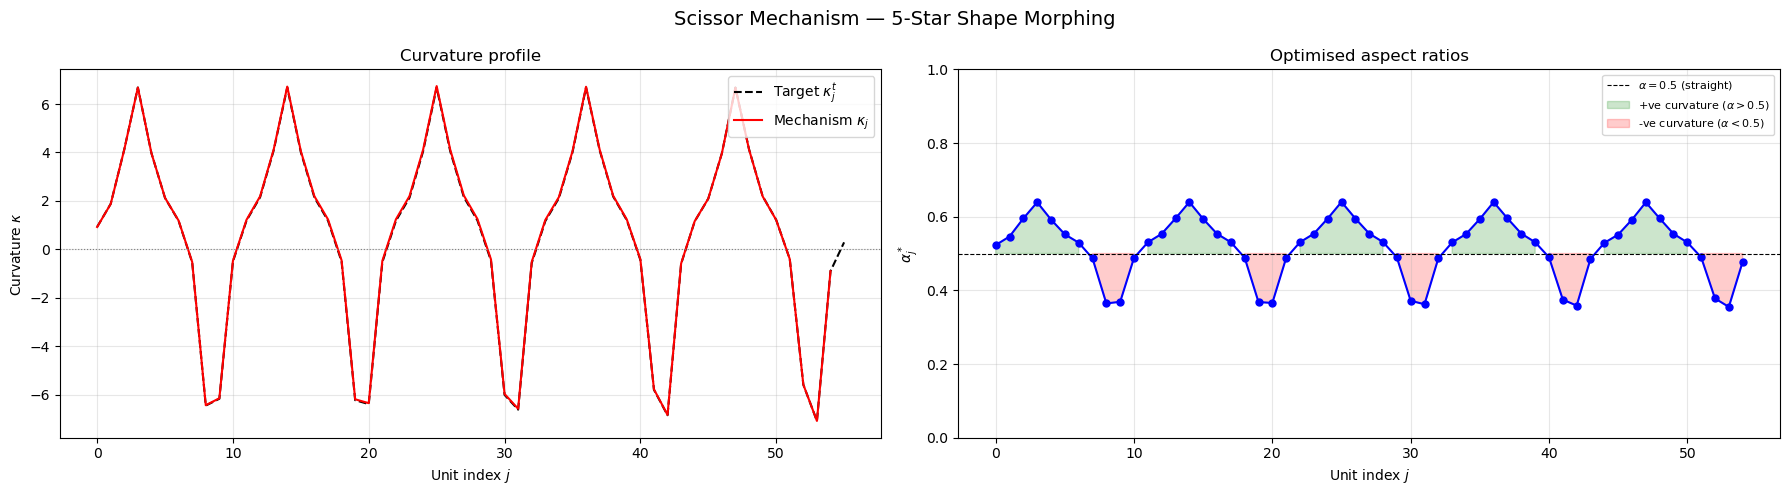

In [ ]:
with torch.no_grad():
    final_pos, final_k = model()
    final_pos = final_pos.cpu()
    final_k   = final_k.cpu()

opt_psi   = np.rad2deg(model.psi_star.item())
opt_rot   = np.rad2deg(model.init_rot.item())
opt_l     = model.get_l().item()
opt_alpha = model.get_alpha().detach().cpu().numpy()

print(f'Psi*: {opt_psi:.2f}°  |  Rot*: {opt_rot:.2f}°  |  l: {opt_l:.4f}')

# --- 3-panel result figure ---
t_xy = target_data.target_coords
p_xy = final_pos.numpy()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Scissor Mechanism — 5-Star Shape Morphing', fontsize=14)


# Panel 1: Curvature profile comparison
axes[0].plot(target_data.target_curvatures.numpy(), 'k--', label='Target $\kappa^t_j$')
axes[0].plot(final_k.numpy(), 'r-', label='Mechanism $\kappa_j$')
axes[0].axhline(0, color='gray', lw=0.8, ls=':')
axes[0].set_title('Curvature profile')
axes[0].set_xlabel('Unit index $j$')
axes[0].set_ylabel('Curvature $\kappa$')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Panel 2: Optimised aspect ratios
axes[1].plot(opt_alpha, 'b-o', ms=5)
axes[1].axhline(0.5, color='k', lw=0.8, ls='--', label='$\\alpha=0.5$ (straight)')
axes[1].fill_between(range(N_UNITS), 0.5, opt_alpha,
                     where=opt_alpha > 0.5, alpha=0.2, color='green',
                     label='+ve curvature ($\\alpha>0.5$)')
axes[1].fill_between(range(N_UNITS), 0.5, opt_alpha,
                     where=opt_alpha < 0.5, alpha=0.2, color='red',
                     label='-ve curvature ($\\alpha<0.5$)')
axes[1].set_title('Optimised aspect ratios')
axes[1].set_xlabel('Unit index $j$')
axes[1].set_ylabel(r'$\alpha^*_j$')  # ← Fixed with raw string
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
